In [1]:
# import h5py
import time
import torch
import matplotlib.pyplot as plt
import math
import pandas as pd
import cv2
import numpy as np
import random
from sklearn.preprocessing import LabelEncoder

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cpu


# CNN

In [3]:
bee_data = pd.read_csv('data/bees/bee_data.csv')
bee_data.shape

(5172, 9)

In [4]:
bee_data.select_dtypes(include=['object'])['subspecies'].unique()

array(['-1', 'Italian honey bee', 'VSH Italian honey bee',
       'Carniolan honey bee', 'Russian honey bee',
       '1 Mixed local stock 2', 'Western honey bee'], dtype=object)

In [5]:
label_encoder = LabelEncoder()
bee_labels_categ = bee_data['subspecies'].drop(bee_data[bee_data['subspecies']=='-1'].index).to_numpy()
label_encoder.fit(bee_labels_categ)
label_encoder.classes_
bee_labels = label_encoder.transform(bee_labels_categ)
bee_labels.shape  


(4744,)

In [6]:
bee_img_files = bee_data['file'].drop(bee_data[bee_data['subspecies']=='-1'].index)
del(bee_data)

In [7]:
bee_img_files

74      017_029.png
75      017_015.png
76      017_001.png
77      017_000.png
78      017_014.png
           ...     
5157    033_087.png
5158    033_093.png
5159    033_092.png
5160    033_096.png
5161    033_097.png
Name: file, Length: 4744, dtype: object

In [8]:
temp_img = cv2.imread('data/bees/bee_imgs/' + bee_img_files.iloc[0])
resized_dims = (24,24)
N = len(bee_img_files)
bee_images = np.zeros(shape=(N,*resized_dims, 3))
bee_images.shape
for i in range(len(bee_img_files)):
    file_name = bee_img_files.iloc[i]
    image = cv2.imread('data/bees/bee_imgs/' + file_name)
    image_resized = cv2.resize(image, resized_dims)
    bee_images[i] = image_resized
    # print(file_name, image.shape, image_resized.shape, bee_images[i].shape)
    # print(np.array_equal(image_resized, bee_images[i]))
    # plt.subplot(1,2,1)
    # plt.imshow(bee_images[i].astype(dtype=int))
    # plt.subplot(1,2,2)
    # plt.imshow(image_resized)
    # break
bee_images = np.flip(bee_images.astype(int), axis=3)
bee_images.shape

(4744, 24, 24, 3)

In [ ]:
data_split_N = int(N * .8)
X_train = bee_images[0:data_split_N]
Y_train = bee_labels[0:data_split_N]
X_test = bee_images[data_split_N+1:]
Y_test = bee_images[data_split_N+1:]

NameError: name 'bee_images' is not defined

In [ ]:
del(bee_images)
del(bee_labels)

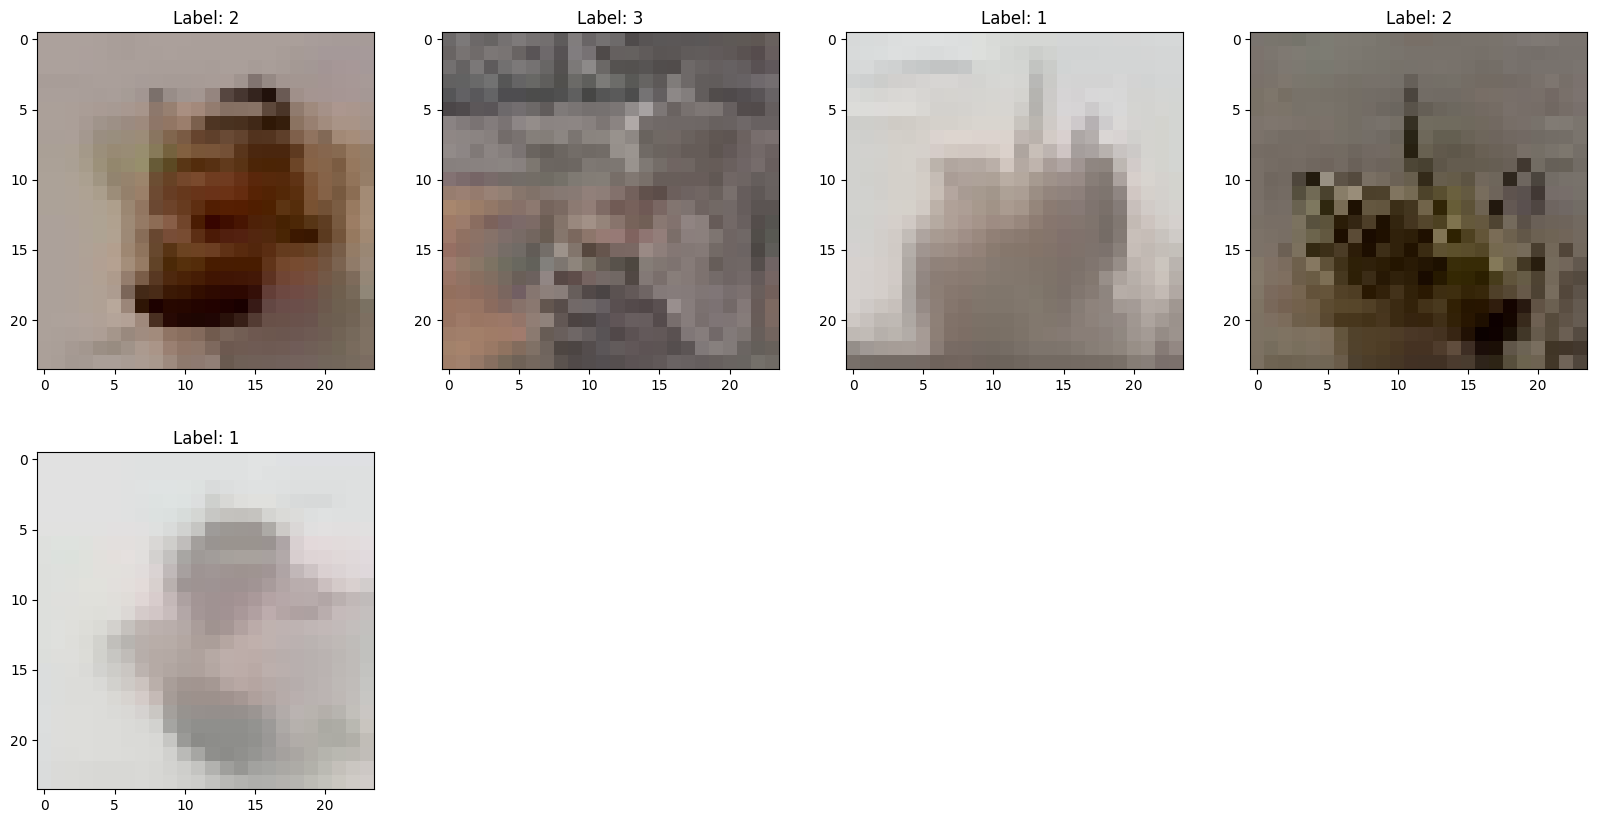

In [12]:
# bee_labels.unique()
# Display images

def display_images(images, labels):
    cols = 4
    rows = math.ceil(len(images) / cols)
    plt.figure(figsize=(20, 10))
    index = 0

    for x in zip(images, labels):
        # image = x[0].cpu()
        # label = x[1].cpu()
        image = x[0]
        label = x[1]
        plt.subplot(rows, cols, index + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Label: {label}")
        # plt.axis("off")
        index += 1

# plt.imshow(bee_images[2])

indices = [random.randint(0, X_train.shape[0]) for _ in range(5)]
images = [X_train[index] for index in indices]
labels = [Y_train[index] for index in indices]

display_images(images, labels)


In [13]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [14]:
resized_dims[0] * resized_dims[1] * 64 / 16

2304.0

In [15]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Input image size: 24 * 24 * 3 (3 channels)

        # Layer Set 1: Convolutional Layer -> ReLU Layer -> Pooling Layer
        self.conv_layer_1 = nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2)
        self.bn_1 = nn.BatchNorm2d(32)
        self.relu_1 = nn.ReLU()

        self.max_pool_1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Layer Set 2: Conv Layer -> ReLU Layer -> Max Pool Layer
        self.conv_layer_2 = nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2)
        self.bn_2 = nn.BatchNorm2d(64)
        self.relu_2 = nn.ReLU()

        self.max_pool_2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected layers: Input (509 neurons) -> FC 1 (256 neurons) with ReLU -> FC 2 (128 neurons) with ReLU -> FC 3/Output (6 classes)
        print(resized_dims[0])
        feat_am = 64 * resized_dims[0] * resized_dims[1] // 16
        self.fc_1 = nn.Linear(in_features=feat_am, out_features=256)
        self.fc_1_relu = nn.ReLU()
        self.dropout_1 = nn.Dropout(0.2)

        self.fc_2 = nn.Linear(in_features=256, out_features=128)
        self.fc_2_relu = nn.ReLU()
        self.dropout_2 = nn.Dropout(0.2)

        self.fc_3 = nn.Linear(in_features=128, out_features=6)

    def forward(self, X):
        # Conv Layer 1
        
        # print('0', X.shape)
        out = self.conv_layer_1(X)
        out = self.bn_1(out)
        # out = self.relu_1(out)
        # print('1', out.shape)

        out = self.max_pool_1(out)
        # print('1.5', out.shape)

        # Conv Layer 2
        out = self.conv_layer_2(out)
        out = self.bn_2(out)
        # out = self.relu_2(out)
        # print('2', out.shape)

        out = self.max_pool_2(out)
        # print('3', out.shape)

        # Flatten
        out = out.reshape(out.size(0), -1)
        # print('4', out.shape)

        # FC Layers
        out = self.fc_1(out)
        out = self.fc_1_relu(out)
        out = self.dropout_1(out)
        # print('5', out.shape)

        out = self.fc_2(out)
        out = self.fc_2_relu(out)
        out = self.dropout_2(out)
        # print('6', out.shape)

        out = self.fc_3(out)
        # print('7', out.shape)

        return out

In [16]:
batch_size = 32
total_epochs = 250
learning_rate = .00005
cnn_model = CNNModel().to(device)

24


In [17]:
error = nn.CrossEntropyLoss()

# SGD Optimizer
optimizer = torch.optim.SGD(cnn_model.parameters(), lr=learning_rate)

In [18]:
# data = Dataset()
# for idx, (data, image) in enumerate(train_dataset):
#     print(idx)
type(X_train)
type(Y_train)

numpy.ndarray

In [19]:
train_dataset = CustomDataset(torch.from_numpy(X_train.copy()), torch.from_numpy(Y_train.copy()))
# rain_dataset = CustomDataset(bee_images,bee_labels)
train_data = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# cnn_model


In [20]:
test = ([X_train],[Y_train])
for (image,label) in enumerate(test):
    print(image,len(label))

0 1
1 1


In [ ]:
num_of_iterations = X_train.shape[0] // batch_size
count = 0
loss_list = []
iteration_list = []

training_start_time = time.time()

for epoch in range(total_epochs):
    for i, (images, labels) in enumerate(train_data):
        images = images.float()
        images = images.permute(0, 3, 1, 2)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        output = cnn_model.forward(images)

        # Calculate loss
        loss = error(output, labels)

        # Backpropagation and calculate gradients
        loss.backward()

        # Update parameters
        optimizer.step()

        count += 1
        loss_list.append(loss)
        iteration_list.append(count)

        if i % 4 == 0:
            print(f"Epoch: [{epoch + 1}/{total_epochs}], step: [{i + 1}/{num_of_iterations}], loss: {loss.data:.4f}")
        

training_end_time = time.time()

print(f"\nTotal training time: {training_end_time - training_start_time} seconds")

Epoch: [1/250], step: [1/118], loss: 1.8172
Epoch: [1/250], step: [5/118], loss: 1.8018
Epoch: [1/250], step: [9/118], loss: 1.7597
Epoch: [1/250], step: [13/118], loss: 1.7890
Epoch: [1/250], step: [17/118], loss: 1.7673
Epoch: [1/250], step: [21/118], loss: 1.8116
Epoch: [1/250], step: [25/118], loss: 1.7599
Epoch: [1/250], step: [29/118], loss: 1.7975
Epoch: [1/250], step: [33/118], loss: 1.7839
Epoch: [1/250], step: [37/118], loss: 1.7713
Epoch: [1/250], step: [41/118], loss: 1.7751
Epoch: [1/250], step: [45/118], loss: 1.7640
Epoch: [1/250], step: [49/118], loss: 1.7508
Epoch: [1/250], step: [53/118], loss: 1.7634
Epoch: [1/250], step: [57/118], loss: 1.7724
Epoch: [1/250], step: [61/118], loss: 1.7742
Epoch: [1/250], step: [65/118], loss: 1.7473
Epoch: [1/250], step: [69/118], loss: 1.7768
Epoch: [1/250], step: [73/118], loss: 1.7390
Epoch: [1/250], step: [77/118], loss: 1.7346
Epoch: [1/250], step: [81/118], loss: 1.7338
Epoch: [1/250], step: [85/118], loss: 1.7392
Epoch: [1/250

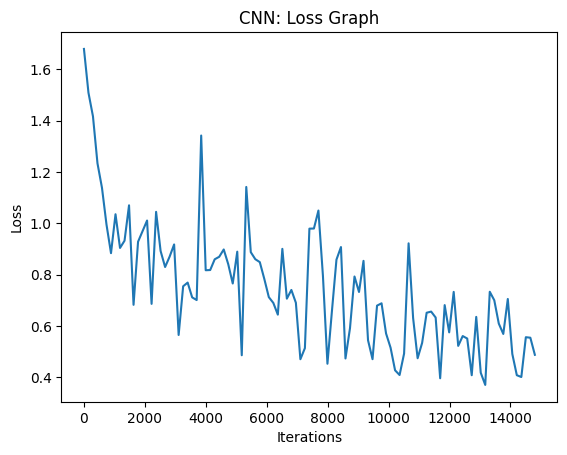

In [ ]:
# Loss Graph

loss_list_numpy = np.array([loss.detach().cpu().numpy() for loss in loss_list])[::num_of_iterations]
# iteration_list_stride = i

plt.plot(iteration_list[::num_of_iterations], loss_list_numpy)

plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.title("CNN: Loss Graph")

plt.show()

In [ ]:
test_dataset = CustomDataset(X_test, y_test)

test_data = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
with torch.no_grad():
    total_test = 0
    total_correct = 0

    for i, (images, labels) in enumerate(test_data):
        images = images.float()
        images = images.permute(0, 3, 1, 2)

        output = cnn_model.forward(images)

        _, predictions = torch.max(output, 1)

        total_correct += (predictions == labels).sum().item()
        total_test += labels.shape[0]

print(f"Total correct predictions: {total_correct}")
print(f"Total samples: {total_test}")
print(f"Accuracy: {total_correct / total_test * 100:.3f}%")